In [686]:
import numpy as np
import matplotlib.pyplot as plt
from gridworld_env import get_task1_gridworld, get_task2_gridworld, get_task3_gridworld
from utils import paint_gridworld

## A Look Around GridWorld

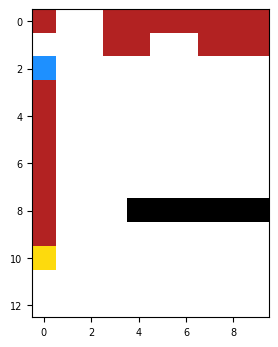

In [3]:
# Initiating the Environment. The method get_task1_gridworld
# initialises the environment for the task 1. Similarly there are methods to initialise the environment 
# for the other tasks
env1 = get_task1_gridworld()

# This is how the environment looks like
paint_gridworld(env1, figsize=(4,4), ticksize=7)

## Example of running a simulation 

In [11]:
reward_lst = []

# Initialise the environment
# An arbitary gamma value is used here. You may need to change this!
env1 = get_task1_gridworld()

# Reset the environment to start from the starting location. 
# The reset() method returns the state, reward, and whether the episode is done or not
# More information can be found under the definition of the method
_, state, reward, done = env1.reset()
reward_lst.append(reward)

# While the trial is not done, i.e. the agent has not fallen into lava,
# the maximum length of the episode has not been exceeded, and the target has not been reached
while not done:
    
    # Take a step using the step() function and passing in one of the available actions [0, 1, 2, 3] 
    # corresponding to ['N', 'S', 'E', 'W']
    # More information can be found under the definition of the method
    # In this very simple example for each step we choose a random action
    _, state, reward, done = env1.step(np.random.choice(4))
    reward_lst.append(reward)

print(f'Collected rewards of an episode: {reward_lst}')

Collected rewards of an episode: [0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0

In [106]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_derivative(x):
    return sigmoid(x) * (1 - sigmoid(x))

class Q_agent():
# The solve method should take the n_episodes and env as a parameter, 
# but otherwise you can modify the definition of this method
  def solve(self, env, n_episodes=500, gamma=0.1, alpha=0.1, epsilon=0.1, first_hidden_size=10, second_hidden_size=10):
    """
    Solve a given GridWorld environment using Q-learning
    input: env {GridWorld object} -- GridWorld to solve
    output:
      - policy {np.array} -- Optimal policy found to solve the given GridWorld environment
      - total_rewards {list of float} -- Corresponding list of successive total non-discounted sum of reward for each trial
      - total_steps {list of float} -- Corresponding list of successive total non-discounted sum of steps for each trial
    """
    current_loc = env._starting_loc
    self.states = env.get_state_size()
    self.actions = env.get_action_size()
    self.first_hidden_size = first_hidden_size
    self.second_hidden_size = second_hidden_size
    shape = env.get_gridshape()
    self.Q = np.zeros((self.states, self.actions))
    self.W1 = np.random.randn(self.states, self.first_hidden_size) * 0.01
    self.b1 = np.zeros(self.first_hidden_size)
    self.W2 = np.random.randn(self.first_hidden_size, self.second_hidden_size) * 0.01
    self.b2 = np.zeros(self.second_hidden_size)
    self.W3 = np.random.rand(self.second_hidden_size, self.actions) * 0.01
    self.b3 = np.zeros(self.actions)
    print("Before training:")
    print(f"Layer 1 weight/bias: {self.W1}/{self.b1}")
    print(f"Layer 2 weight/bias: {self.W2}/{self.b2}")
    print(f"Layer 3 weight/bias: {self.W3}/{self.b3}\n")
    self._alpha = alpha#Learning Rate
    self._epsilon = epsilon#Explore Rate
    self._gamma = gamma#Discount
    total_steps = []
    policy_lst = []
    total_rewards = []

    for e in range(n_episodes):
      _, state, reward, done = env.reset()
      current_total_steps = 0
      current_policy = [state]
      rewards = []
      rewards.append(reward)
      # While the trial is not done, i.e. the agent has not fallen into lava,
      # the maximum length of the episode has not been exceeded, and the target has not been reached
      while not done:
        # Take a step using the step() function and passing in one of the available actions [0, 1, 2, 3] 
        # corresponding to ['N', 'S', 'E', 'W']
        # More information can be found under the definition of the method
        # In this very simple example for each step we choose a random action
        action = self.epsilon_greedy_policy(state)
        _, next_state, reward, done = env.step(action)
        self.update_Q(state, action, next_state, reward)
        state = next_state
        rewards.append(reward)
        current_policy.append(state)
        current_total_steps += 1
      
      average_reward = np.average(rewards)
      if average_reward > 0:
        print(current_policy)
      total_rewards.append(average_reward)
      total_steps.append(current_total_steps)
      policy_lst.append(current_policy)

    index_of_best = np.argmax(total_rewards)
    policy = policy_lst[index_of_best]

    # You may use these outputs to plot graphs
    #print(f"Q VALUES: {self.Q}")
    if e == n_episodes-1:
      print("After training:")
      print(f"Layer 1 weight/bias: {self.W1}/{self.b1}")
      print(f"Layer 2 weight/bias: {self.W2}/{self.b2}")
      print(f"Layer 3 weight/bias: {self.W3}/{self.b3}\n")
    return policy, total_rewards, total_steps

  def update_Q(self, state, action, next_state, reward):
    X = np.zeros((1, self.states))
    X[0, state] = 1
    next_state_X = np.zeros((1, self.states))
    next_state_X[0, next_state] = 1

    hidden1 = sigmoid(np.dot(X, self.W1) + self.b1)
    hidden2 = sigmoid(np.dot(hidden1, self.W2) + self.b2)
    q_values = sigmoid(np.dot(hidden2, self.W3) + self.b3)

    next_hidden1 = sigmoid(np.dot(next_state_X, self.W1) + self.b1)
    next_hidden2 = sigmoid(np.dot(next_hidden1, self.W2) + self.b2)
    next_q_values = sigmoid(np.dot(next_hidden2, self.W3) + self.b3)

    target = reward + self._gamma * np.max(next_q_values)
    adjusted_target = np.copy(q_values)
    adjusted_target[0, action] = target

    # Compute the error terms
    delta_output = (adjusted_target - q_values) * sigmoid_derivative(np.dot(hidden2, self.W3) + self.b3)
    delta_hidden2 = np.dot(delta_output, self.W3.T) * sigmoid_derivative(np.dot(hidden1, self.W2) + self.b2)
    delta_hidden1 = np.dot(delta_hidden2, self.W2.T) * sigmoid_derivative(np.dot(X, self.W1) + self.b1)

    # Compute gradients
    grad_W3 = np.dot(hidden2.T, delta_output)
    grad_b3 = np.sum(delta_output, axis=0)
    grad_W2 = np.dot(hidden1.T, delta_hidden2)
    grad_b2 = np.sum(delta_hidden2, axis=0)
    grad_W1 = np.dot(X.T, delta_hidden1)
    grad_b1 = np.sum(delta_hidden1, axis=0)

    # Update weights and biases
    self.W3 += self._alpha * grad_W3
    self.b3 += self._alpha * grad_b3
    self.W2 += self._alpha * grad_W2
    self.b2 += self._alpha * grad_b2
    self.W1 += self._alpha * grad_W1
    self.b1 += self._alpha * grad_b1

    #self.Q[state, action] += self._alpha * (reward + self._gamma*np.max(self.Q[next_state]) - self.Q[state, action])

  def epsilon_greedy_policy(self, state):
    #Determine optimal action(s)
    X = np.zeros((1, self.states))
    X[0, state] = 1
    hidden1 = sigmoid(np.dot(X, self.W1) + self.b1)
    hidden2 = sigmoid(np.dot(hidden1, self.W2) + self.b2)
    q_values = sigmoid(np.dot(hidden2, self.W3) + self.b3)

    #max_value = np.max(self.Q[state])
    #optimal_actions = []
    #for action in range(self.actions):
    #  if self.Q[state, action] == max_value:
    #    optimal_actions.append(action)
    #Determine whether the agent follows the optimal action or chooses to explore
    if np.random.rand() < self._epsilon:
      return np.random.randint(self.actions)
    else:
      choice = np.argmax(q_values)
      #print(choice)
      return choice


In [302]:
class SARSA_agent():
  # The solve method should take the n_episodes and env as a parameter, 
  # but otherwise you can modify the definition of this method
  def solve(self, env, n_episodes=500, 
             # Extra parameters:
            gamma=0.1, alpha=0.1, epsilon=0.1, ):
    """
    Solve a given GridWorld environment using SARSA
    input: env {GridWorld object} -- GridWorld to solve
    output:
      - policy {np.array} -- Optimal policy found to solve the given GridWorld environment
      - total_rewards {list of float} -- Corresponding list of successive total non-discounted sum of reward for each trial
      - total_steps {list of float} -- Corresponding list of successive total non-discounted sum of steps for each trial
    """

    # Initialise your variables
    self._alpha = alpha#Learning rate
    self._gamma = gamma#Discount
    self._epsilon = epsilon#Explore rate
    self.Q = np.zeros((env.get_state_size(), env.get_action_size()))
    total_steps = []
    policy_lst = []
    total_rewards = []

    ####
    # Add your code here
    # WARNING: this agent only has access to env.reset() and env.step()
    # You should not use env.get_absorbing() to compute any value
    ####

    for e in range(n_episodes):
      _, state, reward, done = env.reset()
      current_total_steps = 0
      current_policy = [state]
      rewards = []
      rewards.append(reward)

      action, optimal_action = self.epsilon_greedy_policy(state, env)

      while not done:
        _, next_state, reward, done = env.step(action)
        next_action, optimal_action = self.epsilon_greedy_policy(next_state, env)
        self.update_Q(state, action, next_state, next_action, reward)
        state = next_state
        action = next_action
        rewards.append(reward)
        current_policy.append(state)
        current_total_steps += 1
      
      total_rewards.append(np.average(rewards))
      total_steps.append(current_total_steps)
      policy_lst.append(current_policy)

    index_of_best = np.argmax(total_rewards)
    policy = policy_lst[index_of_best]
    
    # You may use these outputs to plot graphs
    return policy, total_rewards, total_steps

  def update_Q(self, state, action, next_state, next_action, reward):
    #Q(s, a) ← Q(s, a) + η * [r + γ * Q(s', a') - Q(s, a)] == SARSA
    self.Q[state, action] += self._alpha * (reward + self._gamma*self.Q[next_state, next_action] - self.Q[state, action])

  def epsilon_greedy_policy(self, state, env):
    #Determine optimal action(s)
    max_value = np.max(self.Q[state])
    optimal_actions = []
    for action in range(env.get_action_size()):
      if self.Q[state, action] == max_value:
        optimal_actions.append(action)
    #Determine whether the agent follows the optimal action or chooses to explore
    if np.random.rand() < self._epsilon:
      return np.random.choice(4), np.random.choice(optimal_actions)
    else:
      action = np.random.choice(optimal_actions)
      return action, action

# Task 1 - Single Target, Deterministic Rewards:

In [99]:
# Example of Hyperparameters
# This is just an example, you can add to this depending on which method you utilise

s_gamma_1 = 0.57 #Discount
s_alpha_1 = 0.24 #Learning Rate
s_epsilon_1 = 0.01 #Explore Rate
s_n_episodes_1 = 1000

q_gamma_1 = 0.7
q_alpha_1 = 0.05
q_epsilon_1 = 0.35
q_n_episodes_1 = 1000
q_first_hidden_size_1 = 50
q_second_hidden_size_1 = 30

In [17]:
# This should be the definition of the gridworld for task 1. DO NOT CHANGE THIS
env1 = get_task1_gridworld()

In [100]:
# Example of running SARSA
agent = SARSA_agent()
policy, sarsa_rewards_1, total_steps = agent.solve(env1, gamma=s_gamma_1, alpha=s_alpha_1, epsilon=s_epsilon_1, n_episodes=s_n_episodes_1)

loc_policy = []
for i in range(len(policy)):
    loc_policy.append(env1.get_loc_from_state(policy[i]))

print(f"POLICY: {loc_policy}")
print(f"TOTAL REWARD: {sarsa_rewards_1}")
print(f"TOTAL STEPS: {total_steps}")

POLICY: [(10, 0), (10, 1), (9, 1), (8, 1), (7, 1), (6, 1), (5, 1), (4, 1), (3, 1), (2, 1), (2, 0)]
TOTAL REWARD: [-0.8333333333333334, -0.1724137931034483, -0.1, -0.03968253968253968, -0.03759398496240601, -0.13333333333333333, 0.0, 0.0, 0.0, -0.021413276231263382, -0.02976190476190476, 0.0, -0.3333333333333333, -0.02159827213822894, -0.03802281368821293, 0.0, -0.05319148936170213, -0.029154518950437316, 0.0, 0.0, 0.0, -0.020876826722338204, -0.0228310502283105, -0.06756756756756757, 0.0, -0.022935779816513763, -0.02493765586034913, 0.0, 0.0, -0.04048582995951417, 18.51851851851852, 6.756756756756757, 2.1367521367521367, -0.031545741324921134, -0.11627906976744186, 1.1160714285714286, 4.237288135593221, 2.9411764705882355, 2.304147465437788, 5.4945054945054945, 1.408450704225352, 27.77777777777778, 5.2631578947368425, 5.747126436781609, 9.803921568627452, -0.04524886877828054, 14.705882352941176, 31.25, 38.46153846153846, 45.45454545454545, 45.45454545454545, 45.45454545454545, 45.4545

In [107]:
# Example of running Q-Learning
agent = Q_agent()
policy, q_learning_rewards_1, total_steps = agent.solve(env1, gamma=q_gamma_1, alpha=q_alpha_1, epsilon=q_epsilon_1, n_episodes=q_n_episodes_1, first_hidden_size=q_first_hidden_size_1, second_hidden_size=q_second_hidden_size_1)

loc_policy = []
for i in range(len(policy)):
    loc_policy.append(env1.get_loc_from_state(policy[i]))

print(f"POLICY: {loc_policy}")
print(f"TOTAL REWARD: {q_learning_rewards_1}")
print(f"TOTAL STEPS: {total_steps}")

Before training:
Layer 1 weight/bias: [[ 9.76576734e-03  1.15173533e-02 -5.09284617e-03 ...  2.20100267e-02
  -4.75133672e-03 -1.37496658e-02]
 [-1.54083268e-02 -3.76974060e-04  1.18123524e-02 ... -7.00237034e-03
  -1.77456023e-03 -4.68592067e-03]
 [ 1.07127049e-03 -3.29233190e-03  2.30991453e-03 ...  1.45287061e-02
   2.34227924e-03 -1.21021447e-02]
 ...
 [ 4.25940524e-03  5.92410479e-03 -1.36743262e-02 ... -7.18289861e-03
   9.41767432e-03  1.07839920e-02]
 [-9.93240285e-03  2.01490156e-02  5.91079037e-03 ...  3.63861885e-03
  -4.19836782e-03 -1.97105369e-03]
 [ 1.45474022e-02 -7.23535166e-05 -4.02153295e-03 ...  5.58496618e-03
  -8.98765280e-03  1.86643675e-02]]/[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0.]
Layer 2 weight/bias: [[-8.25093811e-03 -3.86164326e-04 -1.49295907e-03 ...  1.12193410e-03
  -4.86187113e-03 -4.69452654e-03]
 [-9.92977696e-05 -1.50410103e-02  7.09484954e

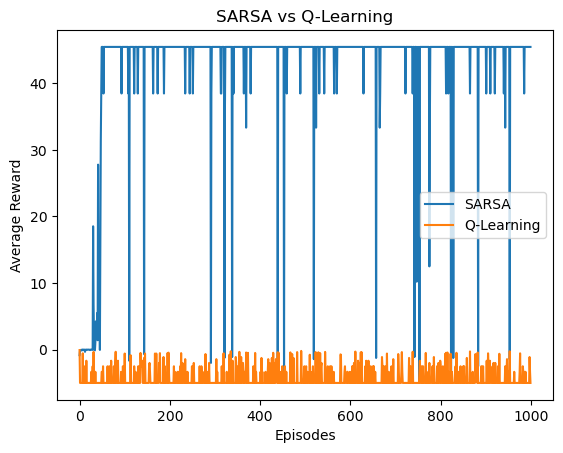

In [105]:
# Do your plots below! Include any new function definitions in this jupyter notebook!
sarsa_average = np.average(sarsa_rewards_1)
q_average = np.average(q_learning_rewards_1)
if sarsa_average > q_average:
    plt.plot(np.mean(np.array(sarsa_rewards_1).reshape(-1, 1), axis=1), label='SARSA')
    plt.plot(np.mean(np.array(q_learning_rewards_1).reshape(-1, 1), axis=1), label='Q-Learning')
else:
    plt.plot(np.mean(np.array(q_learning_rewards_1).reshape(-1, 1), axis=1), label='Q-Learning')
    plt.plot(np.mean(np.array(sarsa_rewards_1).reshape(-1, 1), axis=1), label='SARSA')
plt.xlabel('Episodes')
plt.ylabel('Average Reward')
plt.legend()
plt.title('SARSA vs Q-Learning')
plt.show()

# Task 2 - Dual Targets with Stochastic Rewards

In [109]:
# This should be the definition of the gridworld for task 1. DO NOT CHANGE THIS
env2 = get_task2_gridworld()

In [114]:
# Example of running SARSA
agent = SARSA_agent()

s_gamma_2 = 0.75 #Discount
s_alpha_2 = 0.3 #Learning Rate
s_epsilon_2 = 0.01 #Explore Rate
s_n_episodes_2 = 2500

policy, sarsa_rewards_2, total_steps = agent.solve(env2, gamma=s_gamma_2, alpha=s_alpha_2, epsilon=s_epsilon_2, n_episodes=s_n_episodes_2)

loc_policy = []
for i in range(len(policy)):
    loc_policy.append(env1.get_loc_from_state(policy[i]))

print(f"POLICY: {loc_policy}")
print(f"TOTAL REWARD: {sarsa_rewards_2}")
print(f"TOTAL STEPS: {total_steps}")

POLICY: [(10, 0), (10, 1), (9, 1), (8, 1), (7, 1), (7, 2), (7, 3), (7, 4), (7, 5), (6, 5), (6, 6), (6, 7), (6, 8), (6, 9)]
TOTAL REWARD: [-5.0, -0.08130081300813008, -1.0, -0.07194244604316546, -0.03389830508474576, -1.0, -0.03745318352059925, -0.08928571428571429, -0.11494252873563218, -0.022675736961451247, 0.0, 0.0, 1.7689068191325483, 3.3910812297140707, 1.9368754026022459, -0.11363636363636363, -0.034129692832764506, 4.325669399112154, -0.07462686567164178, -0.045871559633027525, -0.057803468208092484, -0.05405405405405406, 0.6297612482186368, -0.058823529411764705, 3.8551092272175294, 8.518249552228529, 0.5599128824408233, 1.7109190424432947, 0.0, 10.467246615598444, 19.082414200367026, -0.2, -5.0, 0.0, 3.0274997717051058, 12.433309452406421, -0.3448275862068966, 3.092590862126746, 1.8566828070159167, 5.200162100217595, 24.471106809131307, 8.862973996230394, 2.0496177858860007, 4.79339025600968, 2.1279010660878783, 11.053374670880372, 18.275956576217606, 8.09558640552555, 13.0668

In [111]:
# Example of running Q-Learning
q_gamma_2 = 0.75 #Discount
q_alpha_2 = 0.3 #Learning Rate
q_epsilon_2 = 0.05 #Explore Rate
q_n_episodes_2 = 2500
q_first_hidden_size_2 = 50
q_second_hidden_size_2 = 30

agent = Q_agent()
policy, q_learning_rewards_2, total_steps = agent.solve(env2, gamma=q_gamma_2, alpha=q_alpha_2, epsilon=q_epsilon_2, n_episodes=q_n_episodes_2, first_hidden_size=q_first_hidden_size_2, second_hidden_size=q_second_hidden_size_2)

loc_policy = []
for i in range(len(policy)):
    loc_policy.append(env1.get_loc_from_state(policy[i]))

print(f"POLICY: {loc_policy}")
print(f"TOTAL REWARD: {q_learning_rewards_2}")
print(f"TOTAL STEPS: {total_steps}")

Before training:
Layer 1 weight/bias: [[ 2.77600063e-02  3.87895526e-03  1.66625831e-02 ... -5.72776953e-03
  -6.93485236e-03 -2.32422070e-03]
 [-4.32824973e-04 -5.29710664e-03 -1.68774540e-03 ...  1.08162697e-03
   6.09004038e-03  1.02841234e-03]
 [ 3.82056146e-04 -1.43461108e-03  3.61911359e-05 ... -2.59696756e-04
  -5.60186757e-03  1.41845358e-03]
 ...
 [-3.13674999e-03 -2.75581152e-03 -9.90047899e-03 ... -3.46174367e-03
  -1.16481951e-02  2.26400279e-02]
 [ 1.63412426e-02 -1.42508906e-02  2.01144710e-02 ...  1.97060280e-02
  -2.54262186e-03  7.30044769e-03]
 [-5.20246454e-03 -4.62941051e-03 -1.48382879e-02 ...  4.21953674e-03
   1.27416221e-02 -3.83980827e-03]]/[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0.]
Layer 2 weight/bias: [[-0.01622585  0.00357712  0.01767594 ... -0.02008683 -0.00309696
   0.0187863 ]
 [-0.00633584  0.01034854  0.02153177 ... -0.01092642  0.00596046
   0

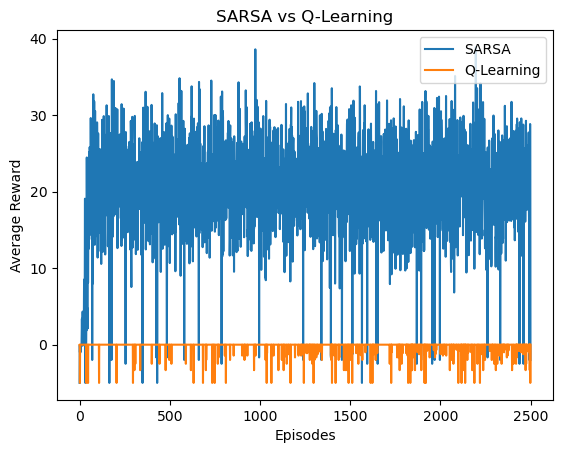

In [115]:
# Do your plots below! Include any new function definitions in this jupyter notebook!
sarsa_average = np.average(sarsa_rewards_2)
q_average = np.average(q_learning_rewards_2)
if sarsa_average > q_average:
    plt.plot(np.mean(np.array(sarsa_rewards_2).reshape(-1, 1), axis=1), label='SARSA')
    plt.plot(np.mean(np.array(q_learning_rewards_2).reshape(-1, 1), axis=1), label='Q-Learning')
else:
    plt.plot(np.mean(np.array(q_learning_rewards_2).reshape(-1, 1), axis=1), label='Q-Learning')
    plt.plot(np.mean(np.array(sarsa_rewards_2).reshape(-1, 1), axis=1), label='SARSA')
plt.xlabel('Episodes')
plt.ylabel('Average Reward')
plt.legend()
plt.title('SARSA vs Q-Learning')
plt.show()

# Task 3 - Stochastic Transitions and Rewards

In [568]:
# This should be the definition of the gridworld for task 1. DO NOT CHANGE THIS
env3 = get_task3_gridworld()

In [674]:
# Example of running SARSA
agent = SARSA_agent()

s_gamma_3 = 0.85 #Discount
s_alpha_3 = 0.3 #Learning Rate
s_epsilon_3 = 0.03 #Explore Rate
s_n_episodes_3 = 5000

policy, sarsa_rewards_3, total_steps = agent.solve(env3, gamma=s_gamma_3, alpha=s_alpha_3, epsilon=s_epsilon_3, n_episodes=s_n_episodes_3)

loc_policy = []
for i in range(len(policy)):
    loc_policy.append(env1.get_loc_from_state(policy[i]))

print(f"POLICY: {loc_policy}")
print(f"TOTAL REWARD: {total_rewards}")
print(f"TOTAL STEPS: {total_steps}")

POLICY: [(10, 0), (10, 1), (10, 2), (10, 3), (9, 3), (8, 3), (8, 2), (7, 2), (7, 1), (7, 2), (6, 2), (5, 2), (4, 2), (3, 2), (2, 2), (2, 1), (2, 0)]
TOTAL REWARD: [-5.0, -0.07092198581560284, -0.10752688172043011, -0.1, -0.30303030303030304, 3.287208540501406, -0.09615384615384616, -0.1111111111111111, -0.2564102564102564, 0.0, 0.0, 2.9808641626643335, -0.02865329512893983, -0.055248618784530384, 2.7300493622180975, 2.757793396373398, 0.5326563344761203, 0.7783689098825558, -1.1111111111111112, 0.0, 0.9457265240564114, 4.685463970520781, -0.06802721088435375, 2.9834932808361274, 9.012858403859733, 6.392531619679419, 17.44022345666054, 3.3120755455194018, 40.5427925839487, 1.6750583607267986, -5.0, 3.8761494619956536, 3.8458940192829854, 1.6201751839360887, 25.647967747035906, 40.42113523908907, 25.530964907189162, 50.400276198606555, 45.25926731900939, 46.97611556064894, 61.044622512460116, 72.10942168301663, 61.935940089507056, 58.32140096875614, 65.42448422626684, 48.56474803968968, 

In [675]:
# Example of running Q-Learning
q_gamma_3 = 0.75 #Discount
q_alpha_3 = 0.35 #Learning Rate
q_epsilon_3 = 0.08 #Explore Rate
q_n_episodes_3 = 5000

agent = Q_agent()
policy, q_learning_rewards_3, total_steps = agent.solve(env3, gamma=q_gamma_3, alpha=q_alpha_3, epsilon=q_epsilon_3, n_episodes=q_n_episodes_3)

loc_policy = []
for i in range(len(policy)):
    loc_policy.append(env1.get_loc_from_state(policy[i]))

print(f"POLICY: {loc_policy}")
print(f"TOTAL REWARD: {total_rewards}")
print(f"TOTAL STEPS: {total_steps}")

POLICY: [(10, 0), (10, 1), (10, 2), (9, 2), (9, 3), (8, 3), (7, 3), (6, 3), (6, 4), (6, 5), (6, 6), (6, 7), (6, 8), (6, 9)]
TOTAL REWARD: [-5.0, -0.07092198581560284, -0.10752688172043011, -0.1, -0.30303030303030304, 3.287208540501406, -0.09615384615384616, -0.1111111111111111, -0.2564102564102564, 0.0, 0.0, 2.9808641626643335, -0.02865329512893983, -0.055248618784530384, 2.7300493622180975, 2.757793396373398, 0.5326563344761203, 0.7783689098825558, -1.1111111111111112, 0.0, 0.9457265240564114, 4.685463970520781, -0.06802721088435375, 2.9834932808361274, 9.012858403859733, 6.392531619679419, 17.44022345666054, 3.3120755455194018, 40.5427925839487, 1.6750583607267986, -5.0, 3.8761494619956536, 3.8458940192829854, 1.6201751839360887, 25.647967747035906, 40.42113523908907, 25.530964907189162, 50.400276198606555, 45.25926731900939, 46.97611556064894, 61.044622512460116, 72.10942168301663, 61.935940089507056, 58.32140096875614, 65.42448422626684, 48.56474803968968, 60.89861205946269, 68.391

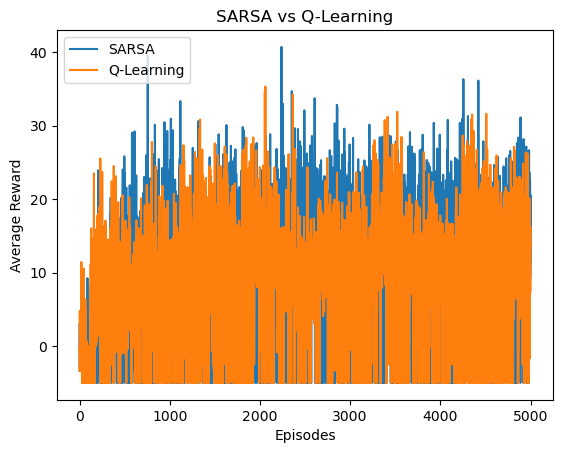

In [676]:
# Do your plots below! Include any new function definitions in this jupyter notebook!
sarsa_average = np.average(sarsa_rewards_3)
q_average = np.average(q_learning_rewards_3)
if sarsa_average > q_average:
    plt.plot(np.mean(np.array(sarsa_rewards_3).reshape(-1, 1), axis=1), label='SARSA')
    plt.plot(np.mean(np.array(q_learning_rewards_3).reshape(-1, 1), axis=1), label='Q-Learning')
else:
    plt.plot(np.mean(np.array(q_learning_rewards_3).reshape(-1, 1), axis=1), label='Q-Learning')
    plt.plot(np.mean(np.array(sarsa_rewards_3).reshape(-1, 1), axis=1), label='SARSA')
plt.xlabel('Episodes')
plt.ylabel('Average Reward')
plt.legend()
plt.title('SARSA vs Q-Learning')
plt.show()